C:\Users\Airly\AppData\Local\Temp\ipykernel_3980\1788084921.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clim['clim_precip_std'].fillna(1.0,inplace=True)
C:\Users\Airly\AppData\Local\Temp\ipykernel_3980\1788084921.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

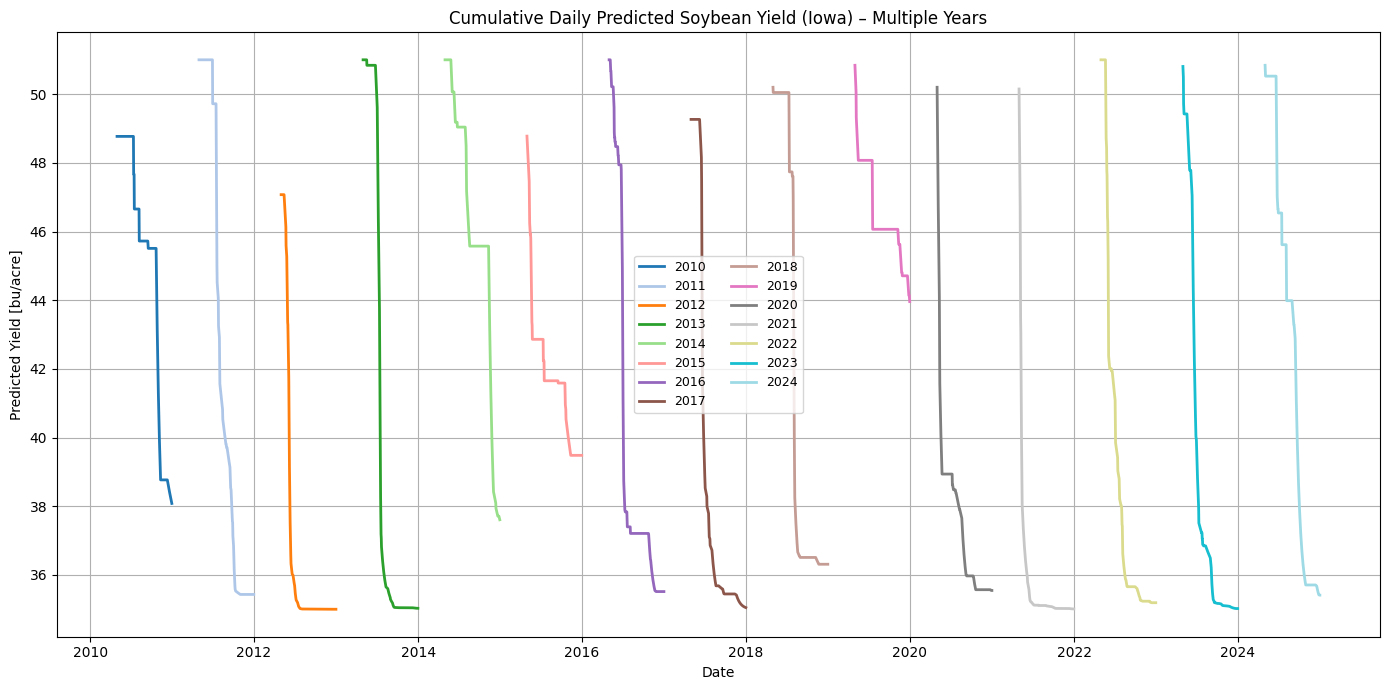

In [12]:
#!/usr/bin/env python3
"""
Cumulative daily soybean yield forecast (Iowa) – multi-year visualization
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# -----------------------------
# 1. Load weather CSV
# -----------------------------
input_csv = "iowa_weather_data.csv"
df_weather = pd.read_csv(input_csv)
df_weather = df_weather.rename(columns={'time':'date', 'prcp':'precip_mm'})
df_weather['date'] = pd.to_datetime(df_weather['date'])
df_weather['year'] = df_weather['date'].dt.year
df_weather['tmean'] = (df_weather['tmin'] + df_weather['tmax']) / 2.0
df_weather['location'] = 'Iowa'

# -----------------------------
# 2. Functions
# -----------------------------
def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))
def drought_penalty(z):
    if np.isnan(z): return 0.0
    if z > -0.5: return 0.0
    elif z > -1.0: return 0.01
    elif z > -1.5: return 0.05
    elif z > -2.0: return 0.15
    elif z > -2.5: return 0.30
    else: return 0.50

# -----------------------------
# 3. Compute daily cumulative yield index
# -----------------------------
def compute_daily_cumulative_yield(df, planting_date_template='05-01',
                                   preplant_days=60, drought_window_days=30,
                                   yield_min=35, yield_max=55,
                                   crit_start_mmdd='07-01', crit_end_mmdd='08-15'):
    df = df.copy()
    df['doy'] = df['date'].dt.dayofyear

    # Climatology
    clim = df.groupby(['location','doy']).agg(
        clim_precip_mean=('precip_mm','mean'),
        clim_precip_std=('precip_mm','std'),
        clim_tmean_mean=('tmean','mean'),
        clim_tmean_std=('tmean','std')
    ).reset_index()
    clim['clim_precip_std'].fillna(1.0,inplace=True)
    clim['clim_tmean_std'].fillna(0.5,inplace=True)
    df = df.merge(clim, on=['location','doy'], how='left')

    daily_forecast = []

    for (loc, yr), sub in df.groupby(['location','year']):
        sub = sub.sort_values('date').set_index('date')
        if sub.empty: continue

        planting_date = pd.to_datetime(f"{yr}-{planting_date_template}")
        planting_date = max(min(planting_date, sub.index.max()-pd.Timedelta(days=30)), sub.index.min()+pd.Timedelta(days=30))

        # Pre-plant
        pre_start = planting_date - pd.Timedelta(days=preplant_days)
        pre_end = planting_date - pd.Timedelta(days=1)
        pre = sub.loc[(sub.index>=pre_start) & (sub.index<=pre_end)]
        if pre.shape[0]<preplant_days*0.5:
            pre = sub.loc[(sub.index>=pd.to_datetime(f"{yr}-03-01")) & (sub.index<=pre_end)]

        pre_mean_t = pre['tmean'].mean() if not pre.empty else np.nan
        pre_total_precip = pre['precip_mm'].sum() if not pre.empty else np.nan
        if not pre.empty:
            pre_clim = clim[(clim['location']==loc)&(clim['doy'].isin(pre['doy']))]
            clim_mean_t = pre_clim['clim_tmean_mean'].mean()
            clim_total_precip = pre_clim['clim_precip_mean'].sum()
            clim_precip_std_sum = pre_clim['clim_precip_std'].replace(0,1).pow(2).sum()**0.5
        else: clim_mean_t = clim_total_precip = clim_precip_std_sum = np.nan

        temp_anom = pre_mean_t - clim_mean_t if not np.isnan(pre_mean_t) else np.nan
        precip_anom = pre_total_precip - clim_total_precip if not np.isnan(pre_total_precip) else np.nan
        precip_anom_z = precip_anom / clim_precip_std_sum if clim_precip_std_sum>0 else np.nan

        warm_wet_risk = sigmoid(max(0,temp_anom)*max(0,precip_anom_z))*0.40 if not np.isnan(temp_anom) and not np.isnan(precip_anom_z) else 0.0
        dry_risk = min(0.6, (-precip_anom_z/2.5)*0.6) if not np.isnan(precip_anom_z) and precip_anom_z<0 else 0.0
        preplant_risk = float(np.clip(max(warm_wet_risk,dry_risk),0.0,0.75))

        # Rolling drought z-score
        rolling_precip = sub['precip_mm'].rolling(window=drought_window_days, min_periods=int(drought_window_days*0.5)).sum()
        doy_series = sub['doy']
        clim_map = clim.set_index(['location','doy'])
        clim_daily = pd.Series(doy_series.map(lambda doy: clim_map.loc[(loc,int(doy)),'clim_precip_mean'] if (loc,int(doy)) in clim_map.index else np.nan), index=sub.index)
        rolling_clim = clim_daily.rolling(window=drought_window_days, min_periods=int(drought_window_days*0.5)).sum()
        clim_std_daily = pd.Series(doy_series.map(lambda doy: clim_map.loc[(loc,int(doy)),'clim_precip_std'] if (loc,int(doy)) in clim_map.index else 1.0), index=sub.index)
        rolling_clim_std = np.sqrt((clim_std_daily**2).rolling(window=drought_window_days, min_periods=int(drought_window_days*0.5)).sum())
        precip_rolling_z = (rolling_precip - rolling_clim)/rolling_clim_std.replace(0,1)

        cumulative_index = 1.0 - preplant_risk
        for dt in sub.index[sub.index >= planting_date]:
            drought_pen = drought_penalty(precip_rolling_z.loc[dt])
            crit_start = pd.to_datetime(f"{yr}-{crit_start_mmdd}")
            crit_end = pd.to_datetime(f"{yr}-{crit_end_mmdd}")
            heat_pen = 0.08 if crit_start <= dt <= crit_end and sub.loc[dt,'tmax']>35 else 0.0
            cumulative_index *= (1.0 - drought_pen)*(1.0 - heat_pen)
            predicted_yield = 35 + cumulative_index*(55-35)
            daily_forecast.append({'date':dt,'year':yr,'predicted_yield_bu_ac':predicted_yield})

    return pd.DataFrame(daily_forecast)

# -----------------------------
# 4. Compute daily forecasts for all years
# -----------------------------
df_daily_all = compute_daily_cumulative_yield(df_weather)
df_daily_all.to_csv("iowa_soy_cumulative_all_years.csv", index=False)

# -----------------------------
# 5. Multi-year plot
# -----------------------------
plt.figure(figsize=(14,7))
years = sorted(df_daily_all['year'].unique())
colors = cm.get_cmap('tab20', len(years))
for i, yr in enumerate(years):
    df_plot = df_daily_all[df_daily_all['year']==yr]
    plt.plot(df_plot['date'], df_plot['predicted_yield_bu_ac'], color=colors(i), lw=2, label=str(yr))

plt.title("Cumulative Daily Predicted Soybean Yield (Iowa) – Multiple Years")
plt.xlabel("Date")
plt.ylabel("Predicted Yield [bu/acre]")
plt.grid(True)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


dlaczego sa okrsy stale predykcji w treakcie sezonyu?
dlaczego predykcje startuja z wysokiego poziomu?
nisko koreluje z rzeczywistymi